In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import cantera as ct

T_supply  = 300.0     # K
P_supply  = 8.4e5     # Pa  (8.4 bar regulated delivery)
P_chamber = 3.55e5    # Pa  (combustor inlet)
mdot      = 8.0e-3    # kg/s

gas = ct.Solution('h2o2.yaml')
gas.TPX = T_supply, P_supply, 'H2:1.0'

rho_H2    = gas.density                          # kg/m³
mu_H2     = gas.viscosity                        # Pa·s
cp_H2     = gas.cp_mass                          # J/kg/K
cv_H2     = gas.cv_mass                          # J/kg/K
gamma_H2  = cp_H2 / cv_H2                        # —
R_H2      = cp_H2 - cv_H2                        # J/kg/K
# Isentropic speed of sound: a = sqrt(gamma * R * T)
# Cantera does not expose a direct speed_of_sound property
# on Solution objects, so we compute from thermodynamic
# quantities which Cantera has already evaluated consistently.
a_H2      = np.sqrt(gamma_H2 * R_H2 * T_supply) # m/s
print("Mach Speed: "+str(a_H2))
source_str = "Cantera (h2o2.yaml, NASA-7 polynomials)"

Mach Speed: 1318.4083245439133


In [ ]:
# LIMIT 1 — COMPRESSIBILITY: Ma < 0.3
#   Below Ma = 0.3 the density variation along the pipe is
#   less than ~4.5% (from isentropic relations), which is the
#   standard threshold below which incompressible flow
#   assumptions introduce less than 1% error in pressure drop
#   calculations (Anderson, Fundamentals of Aerodynamics, §1.10).
#   Above this threshold the Darcy-Weisbach equation as used
#   here is no longer strictly valid and compressible flow
#   corrections are required.
#
# LIMIT 2 — PRESSURE LOSS BUDGET: ΔP < 20% of P_supply
#   The injector must be choked (established in Section 3.2
#   of the paper). The critical pressure ratio for hydrogen
#   (γ = 1.4) is 1.893, requiring P_inj_min = 6.72 bar.
#   With P_supply = 8.4 bar, the total available pressure
#   loss across all line components is:
#   ΔP_budget = 8.4 - 6.72 = 1.68 bar = 20% of supply.
#   Pipe friction must consume only a fraction of this budget,
#   leaving margin for valve losses and fittings.
#   A pipe friction loss of <5% of supply (0.42 bar) is
#   adopted as the design target, leaving 15% for valves.
#
# There is no arbitrary velocity limit. The selection is
# governed entirely by these two engineering constraints.

# Injector choking condition
PR_crit    = ((gamma_H2 + 1) / 2) ** (gamma_H2 / (gamma_H2 - 1))
P_inj_min  = PR_crit * P_chamber
dP_budget  = P_supply - P_inj_min    # Pa — total available line loss
dP_pipe_target = 0.05 * P_supply     # Pa — pipe friction target (<5%)

print("=" * 60)
print("PRESSURE BUDGET AND CHOKING CONDITION")
print("=" * 60)
print(f"  Critical pressure ratio  = {PR_crit:.4f}")
print(f"  Min injector inlet P     = {P_inj_min/1e5:.3f} bar")
print(f"  Total ΔP budget          = {dP_budget/1e5:.3f} bar  "
      f"({dP_budget/P_supply*100:.1f}% of supply)")
print(f"  Pipe friction target     = {dP_pipe_target/1e5:.3f} bar  "
      f"({dP_pipe_target/P_supply*100:.1f}% of supply)")
print(f"  Margin for valves/fittings = {(dP_budget-dP_pipe_target)/1e5:.3f} bar  "
      f"({(dP_budget-dP_pipe_target)/P_supply*100:.1f}% of supply)")
print()

PRESSURE BUDGET AND CHOKING CONDITION
  Critical pressure ratio  = 1.8959
  Min injector inlet P     = 6.730 bar
  Total ΔP budget          = 1.670 bar  (19.9% of supply)
  Pipe friction target     = 0.420 bar  (5.0% of supply)
  Margin for valves/fittings = 1.250 bar  (14.9% of supply)



In [ ]:
pipe_sizes = {
    '1/4"': {'OD_mm': 13.72, 'wall_mm': 2.24},
    '1/2"': {'OD_mm': 21.34, 'wall_mm': 2.77},
    '3/4"': {'OD_mm': 26.67, 'wall_mm': 2.87},
    '1"'  : {'OD_mm': 33.40, 'wall_mm': 3.38},
}
for size, p in pipe_sizes.items():
    D = (p['OD_mm'] - 2 * p['wall_mm']) * 1e-3
    p['ID_mm'] = p['OD_mm'] - 2 * p['wall_mm']
    p['ID_m']  = D
    p['A_m2']  = np.pi / 4 * D**2

print("=" * 60)
print("SCHEDULE 40S PIPE DIMENSIONS (ASME B36.19M)")
print("=" * 60)
print(f"  {'Size':<8} {'OD (mm)':>9} {'Wall (mm)':>11} "
      f"{'ID (mm)':>9} {'A (mm²)':>10}")
print(f"  {'-'*52}")
for size, p in pipe_sizes.items():
    print(f"  {size:<8} {p['OD_mm']:>9.2f} {p['wall_mm']:>11.2f} "
          f"{p['ID_mm']:>9.2f} {p['A_m2']*1e6:>10.3f}")
print()

SCHEDULE 40S PIPE DIMENSIONS (ASME B36.19M)
  Size       OD (mm)   Wall (mm)   ID (mm)    A (mm²)
  ----------------------------------------------------
  1/4"         13.72        2.24      9.24     67.055
  1/2"         21.34        2.77     15.80    196.067
  3/4"         26.67        2.87     20.93    344.055
  1"           33.40        3.38     26.64    557.389



In [ ]:
# ============================================================
# 5. FRICTION FACTOR — COLEBROOK-WHITE
# ============================================================
# The Colebrook-White equation is used throughout. This is the
# accepted implicit equation for the Darcy friction factor in
# fully turbulent and transitional pipe flow (Moody, 1944).
# Surface roughness for drawn stainless steel tube: ε = 0.015 mm
# (Munson et al., Fundamentals of Fluid Mechanics, Table 8.1).

epsilon_m = 0.015e-3   # m — drawn stainless steel roughness

def colebrook_ff(Re, D):
    """
    Darcy friction factor via Colebrook-White (iterative).
    Hagen-Poiseuille used for laminar flow (Re < 2300).
    Conservative turbulent value used in transition zone.
    """
    if Re < 2300:
        return 64.0 / Re
    elif Re < 4000:
        f_lam  = 64.0 / Re
        f_turb = colebrook_ff(4000, D)
        return max(f_lam, f_turb)
    else:
        # Swamee-Jain initial guess
        f = 0.25 / (np.log10(epsilon_m / (3.7 * D) + 5.74 / Re**0.9))**2
        for _ in range(100):
            rhs   = -2.0 * np.log10(
                epsilon_m / (3.7 * D) + 2.51 / (Re * np.sqrt(f)))
            f_new = (1.0 / rhs)**2
            if abs(f_new - f) < 1e-12:
                break
            f = f_new
        return f

In [ ]:
L_values = np.linspace(0.1, 5.0, 1000)   # m — range of pipe lengths

results = {}
for size, p in pipe_sizes.items():
    D  = p['ID_m']
    A  = p['A_m2']
    V  = mdot / (rho_H2 * A)
    Ma = V / a_H2
    Re = rho_H2 * V * D / mu_H2
    f  = colebrook_ff(Re, D)

    # Darcy-Weisbach pressure loss along pipe length
    dP = f * (L_values / D) * 0.5 * rho_H2 * V**2   # Pa

    # Fraction of supply pressure
    dP_frac = dP / P_supply * 100   # %

    # Barlow's formula — hoop stress limited pressure rating
    # P_rated = 2 * S_allow * t / OD
    # 316 SS allowable hoop stress at 300 K: S = 137 MPa
    # Source: ASME B31.3 Process Piping, Table A-1
    S_allow = 137e6   # Pa
    t       = p['wall_mm'] * 1e-3
    OD      = p['OD_mm'] * 1e-3
    P_rated = 2 * S_allow * t / OD   # Pa

    # Kinetic energy per unit volume as fraction of static pressure
    # This is the dynamic pressure ratio — relevant to minor losses
    q_over_P = (0.5 * rho_H2 * V**2) / P_supply

    results[size] = {
        'D'         : D,
        'A'         : A,
        'V'         : V,
        'Ma'        : Ma,
        'Re'        : Re,
        'f'         : f,
        'dP'        : dP,
        'dP_frac'   : dP_frac,
        'P_rated'   : P_rated,
        'q_over_P'  : q_over_P,
        'L_values'  : L_values,
    }

In [ ]:
# ============================================================
# 7. SUMMARY TABLE
# ============================================================

print("=" * 90)
print("FLOW ANALYSIS SUMMARY AT DESIGN CONDITIONS")
print(f"  ṁ = {mdot*1e3:.1f} g/s | P = {P_supply/1e5:.1f} bar | "
      f"T = {T_supply:.0f} K | Source: {source_str}")
print("=" * 90)
print(f"  {'Size':<8} {'ID mm':>7} {'V (m/s)':>9} {'Ma':>8} "
      f"{'Re':>9} {'f':>8} {'ΔP @2m (Pa)':>13} {'ΔP% @2m':>10} "
      f"{'P_rated (bar)':>14}")
print(f"  {'-'*89}")

L_ref_idx = np.argmin(np.abs(L_values - 2.0))
for size, r in results.items():
    print(f"  {size:<8} {pipe_sizes[size]['ID_mm']:>7.2f} {r['V']:>9.2f} "
          f"{r['Ma']:>8.5f} {r['Re']:>9.0f} {r['f']:>8.5f} "
          f"{r['dP'][L_ref_idx]:>13.2f} {r['dP_frac'][L_ref_idx]:>10.4f} "
          f"{r['P_rated']/1e5:>14.1f}")
print()

FLOW ANALYSIS SUMMARY AT DESIGN CONDITIONS
  ṁ = 8.0 g/s | P = 8.4 bar | T = 300 K | Source: Cantera (h2o2.yaml, NASA-7 polynomials)
  Size       ID mm   V (m/s)       Ma        Re        f   ΔP @2m (Pa)    ΔP% @2m  P_rated (bar)
  -----------------------------------------------------------------------------------------
  1/4"        9.24    175.73  0.13329    122482  0.02377      53891.20     6.4156          447.3
  1/2"       15.80     60.10  0.04558     71629  0.02280       3536.12     0.4210          355.7
  3/4"       20.93     34.25  0.02598     54072  0.02294        872.21     0.1038          294.9
  1"         26.64     21.14  0.01603     42482  0.02340        266.24     0.0317          277.3



In [ ]:
print("=" * 65)
print("MAXIMUM FLOW RATE BY ENGINEERING CONSTRAINT")
print(f"  Reference length: 2.0 m | ΔP budget: 5% of P_supply")
print("=" * 65)
print(f"  {'Size':<8} {'Ma<0.3 limit (g/s)':>20} "
      f"{'ΔP<5% budget, 2m (g/s)':>25}")
print(f"  {'-'*57}")

for size, p in pipe_sizes.items():
    D = p['ID_m']
    A = p['A_m2']

    # Ma = 0.3 limit
    mdot_Ma03 = rho_H2 * A * 0.3 * a_H2

    # ΔP = 5% of P_supply over 2m — solve numerically
    mdot_sweep = np.linspace(1e-5, 2.0, 20000)
    V_sw       = mdot_sweep / (rho_H2 * A)
    Re_sw      = rho_H2 * V_sw * D / mu_H2
    f_sw       = np.array([colebrook_ff(Re, D) for Re in Re_sw])
    dP_sw      = f_sw * (2.0 / D) * 0.5 * rho_H2 * V_sw**2
    frac_sw    = dP_sw / P_supply
    idx        = np.argmin(np.abs(frac_sw - 0.05))
    mdot_dP5   = mdot_sweep[idx]

    print(f"  {size:<8} {mdot_Ma03*1e3:>20.1f} {mdot_dP5*1e3:>25.1f}")
print()

MAXIMUM FLOW RATE BY ENGINEERING CONSTRAINT
  Reference length: 2.0 m | ΔP budget: 5% of P_supply
  Size       Ma<0.3 limit (g/s)    ΔP<5% budget, 2m (g/s)
  ---------------------------------------------------------
  1/4"                     18.0                       7.0
  1/2"                     52.6                      29.0
  3/4"                     92.4                      60.9
  1"                      149.7                     114.8



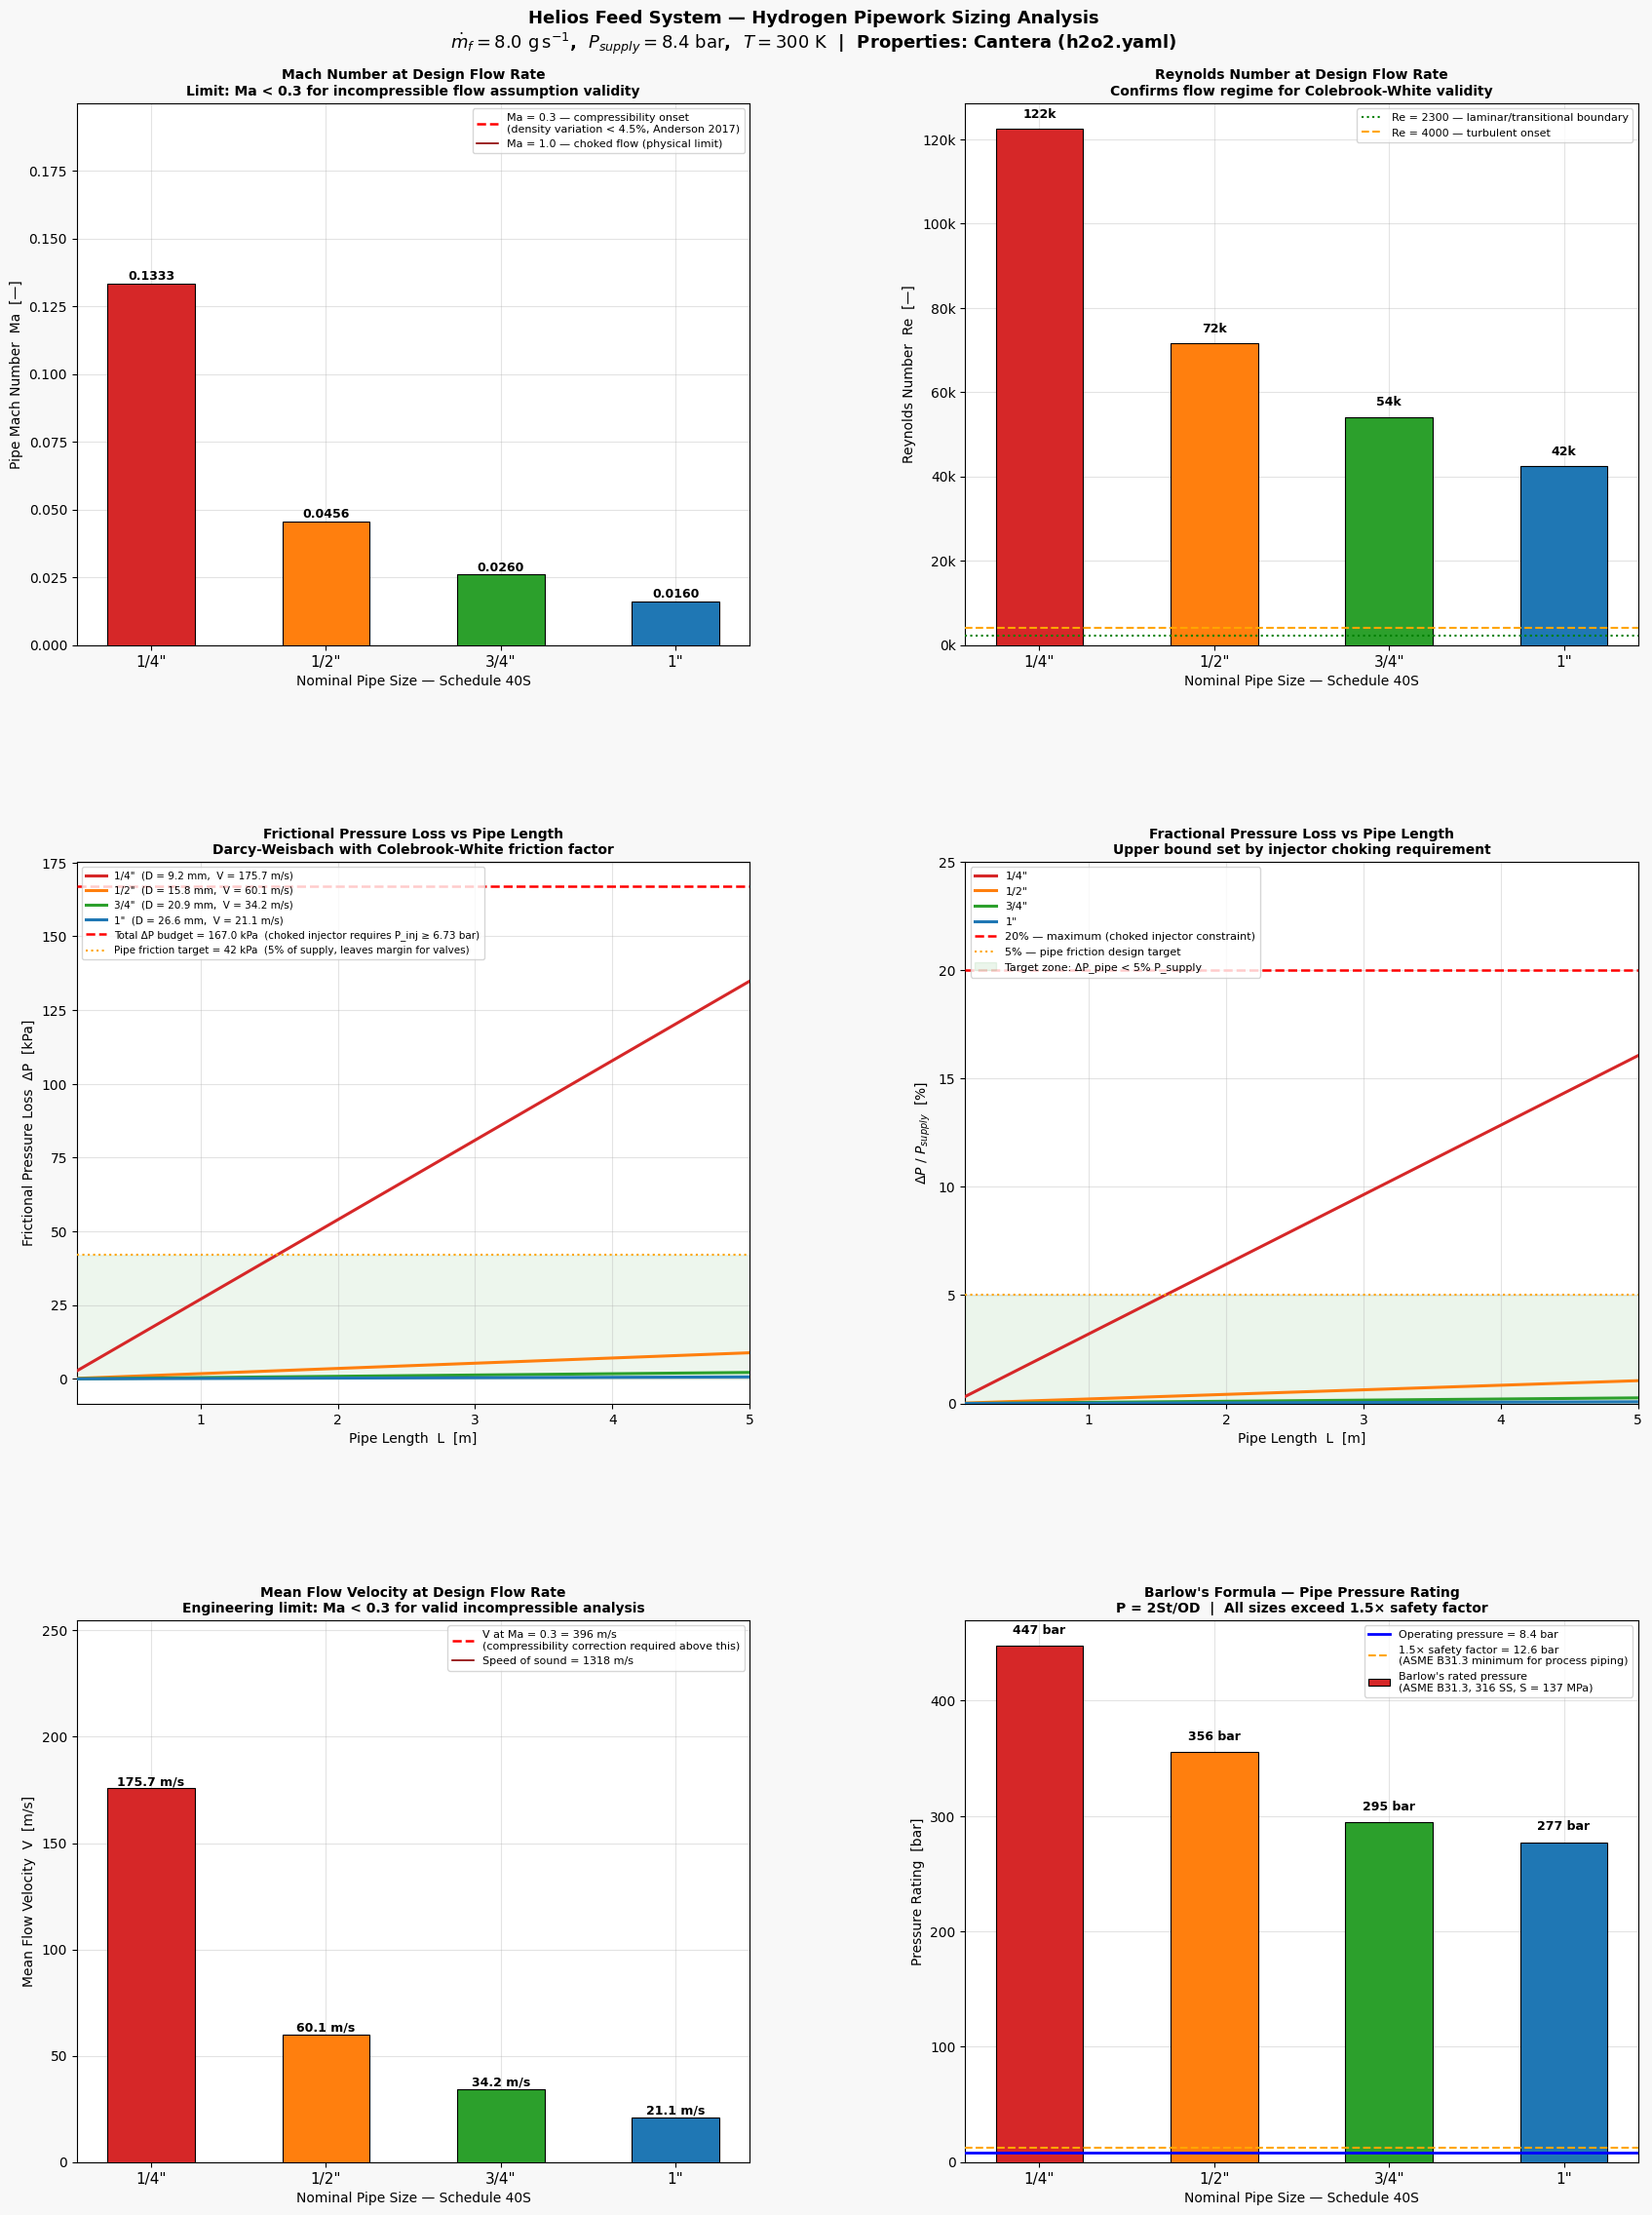

Figure saved: helios_pipework_sizing.png


In [ ]:
colours = {
    '1/4"': '#d62728',
    '1/2"': '#ff7f0e',
    '3/4"': '#2ca02c',
    '1"'  : '#1f77b4',
}

size_labels = list(results.keys())
x_pos       = np.arange(len(size_labels))
bar_cols    = [colours[s] for s in size_labels]

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor('#f8f8f8')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.32,
                        top=0.93, bottom=0.05, left=0.08, right=0.97)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

prop_src = "Cantera (h2o2.yaml)"
fig.suptitle(
    'Helios Feed System — Hydrogen Pipework Sizing Analysis\n'
    rf'$\dot{{m}}_f = {mdot*1e3:.1f}\ \mathrm{{g\,s^{{-1}}}}$,  '
    rf'$P_{{supply}} = {P_supply/1e5:.1f}\ \mathrm{{bar}}$,  '
    rf'$T = {T_supply:.0f}\ \mathrm{{K}}$  |  '
    f'Properties: {prop_src}',
    fontsize=13, fontweight='bold', y=0.97
)

def style_ax(ax):
    ax.set_facecolor('#ffffff')
    ax.grid(alpha=0.35, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    style_ax(ax)

# ---- Plot 1: Mach number ------------------------------------
Ma_vals = [results[s]['Ma'] for s in size_labels]
bars1   = ax1.bar(x_pos, Ma_vals, color=bar_cols, width=0.5,
                  edgecolor='black', linewidth=0.8, zorder=3)
ax1.axhline(0.3, color='red', linestyle='--', linewidth=1.8,
            label='Ma = 0.3 — compressibility onset\n'
                  '(density variation < 4.5%, Anderson 2017)', zorder=4)
ax1.axhline(1.0, color='darkred', linestyle='-', linewidth=1.2,
            label='Ma = 1.0 — choked flow (physical limit)', zorder=4)
for bar, val in zip(bars1, Ma_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.0003,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(size_labels, fontsize=11)
ax1.set_xlabel('Nominal Pipe Size — Schedule 40S', fontsize=10)
ax1.set_ylabel('Pipe Mach Number  Ma  [—]', fontsize=10)
ax1.set_title('Mach Number at Design Flow Rate\n'
              'Limit: Ma < 0.3 for incompressible flow assumption validity',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_ylim(0, max(Ma_vals) * 1.5)

# ---- Plot 2: Reynolds number --------------------------------
Re_vals = [results[s]['Re'] for s in size_labels]
bars2   = ax2.bar(x_pos, Re_vals, color=bar_cols, width=0.5,
                  edgecolor='black', linewidth=0.8, zorder=3)
ax2.axhline(2300, color='green', linestyle=':', linewidth=1.5,
            label='Re = 2300 — laminar/transitional boundary', zorder=4)
ax2.axhline(4000, color='orange', linestyle='--', linewidth=1.5,
            label='Re = 4000 — turbulent onset', zorder=4)
for bar, val in zip(bars2, Re_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2000,
             f'{val/1e3:.0f}k', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(size_labels, fontsize=11)
ax2.set_xlabel('Nominal Pipe Size — Schedule 40S', fontsize=10)
ax2.set_ylabel('Reynolds Number  Re  [—]', fontsize=10)
ax2.set_title('Reynolds Number at Design Flow Rate\n'
              'Confirms flow regime for Colebrook-White validity',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# ---- Plot 3: Absolute pressure loss vs length ---------------
for size in size_labels:
    r = results[size]
    ax3.plot(r['L_values'], r['dP'] / 1e3, color=colours[size],
             linewidth=2.2,
             label=f'{size}  (D = {pipe_sizes[size]["ID_mm"]:.1f} mm,'
                   f'  V = {r["V"]:.1f} m/s)',
             zorder=3)
ax3.axhline(dP_budget / 1e3, color='red', linestyle='--', linewidth=1.8,
            label=f'Total ΔP budget = {dP_budget/1e3:.1f} kPa  '
                  f'(choked injector requires P_inj ≥ {P_inj_min/1e5:.2f} bar)',
            zorder=4)
ax3.axhline(dP_pipe_target / 1e3, color='orange', linestyle=':',
            linewidth=1.5,
            label=f'Pipe friction target = {dP_pipe_target/1e3:.0f} kPa  '
                  f'(5% of supply, leaves margin for valves)',
            zorder=4)
ax3.fill_between(L_values, 0, dP_pipe_target / 1e3,
                 alpha=0.07, color='green')
ax3.set_xlabel('Pipe Length  L  [m]', fontsize=10)
ax3.set_ylabel('Frictional Pressure Loss  ΔP  [kPa]', fontsize=10)
ax3.set_title('Frictional Pressure Loss vs Pipe Length\n'
              'Darcy-Weisbach with Colebrook-White friction factor',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=7.5, loc='upper left')
ax3.set_xlim(L_values[0], L_values[-1])

# ---- Plot 4: Fractional pressure loss -----------------------
for size in size_labels:
    r = results[size]
    ax4.plot(r['L_values'], r['dP_frac'], color=colours[size],
             linewidth=2.2, label=f'{size}', zorder=3)
ax4.axhline(20.0, color='red', linestyle='--', linewidth=1.8,
            label='20% — maximum (choked injector constraint)', zorder=4)
ax4.axhline(5.0, color='orange', linestyle=':', linewidth=1.5,
            label='5% — pipe friction design target', zorder=4)
ax4.fill_between(L_values, 0, 5.0, alpha=0.08, color='green',
                 label='Target zone: ΔP_pipe < 5% P_supply')
ax4.set_xlabel('Pipe Length  L  [m]', fontsize=10)
ax4.set_ylabel(r'$\Delta P\ /\ P_{supply}$  [%]', fontsize=10)
ax4.set_title('Fractional Pressure Loss vs Pipe Length\n'
              'Upper bound set by injector choking requirement',
              fontsize=10, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left')
ax4.set_xlim(L_values[0], L_values[-1])
ax4.set_ylim(0, 25)

# ---- Plot 5: Velocity and compressibility -------------------
V_vals  = [results[s]['V'] for s in size_labels]
bars5   = ax5.bar(x_pos, V_vals, color=bar_cols, width=0.5,
                  edgecolor='black', linewidth=0.8, zorder=3)
# Ma = 0.3 velocity threshold
V_Ma03 = 0.3 * a_H2
ax5.axhline(V_Ma03, color='red', linestyle='--', linewidth=1.8,
            label=f'V at Ma = 0.3 = {V_Ma03:.0f} m/s\n'
                  f'(compressibility correction required above this)',
            zorder=4)
ax5.axhline(a_H2, color='darkred', linestyle='-', linewidth=1.2,
            label=f'Speed of sound = {a_H2:.0f} m/s', zorder=4)
for bar, val in zip(bars5, V_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f} m/s', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(size_labels, fontsize=11)
ax5.set_xlabel('Nominal Pipe Size — Schedule 40S', fontsize=10)
ax5.set_ylabel('Mean Flow Velocity  V  [m/s]', fontsize=10)
ax5.set_title('Mean Flow Velocity at Design Flow Rate\n'
              'Engineering limit: Ma < 0.3 for valid incompressible analysis',
              fontsize=10, fontweight='bold')
ax5.legend(fontsize=8, loc='upper right')
ax5.set_ylim(0, max(V_vals) * 1.45)

# ---- Plot 6: Pressure rating --------------------------------
P_rated_bar = [results[s]['P_rated'] / 1e5 for s in size_labels]
bars6       = ax6.bar(x_pos, P_rated_bar, color=bar_cols, width=0.5,
                      edgecolor='black', linewidth=0.8, zorder=3,
                      label="Barlow's rated pressure\n"
                            "(ASME B31.3, 316 SS, S = 137 MPa)")
ax6.axhline(P_supply / 1e5, color='blue', linestyle='-', linewidth=2.0,
            label=f'Operating pressure = {P_supply/1e5:.1f} bar', zorder=4)
ax6.axhline(P_supply / 1e5 * 1.5, color='orange', linestyle='--',
            linewidth=1.5,
            label=f'1.5× safety factor = {P_supply/1e5*1.5:.1f} bar\n'
                  f'(ASME B31.3 minimum for process piping)',
            zorder=4)
for bar, val in zip(bars6, P_rated_bar):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 8,
             f'{val:.0f} bar', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(size_labels, fontsize=11)
ax6.set_xlabel('Nominal Pipe Size — Schedule 40S', fontsize=10)
ax6.set_ylabel('Pressure Rating  [bar]', fontsize=10)
ax6.set_title("Barlow's Formula — Pipe Pressure Rating\n"
              "P = 2St/OD  |  All sizes exceed 1.5× safety factor",
              fontsize=10, fontweight='bold')
ax6.legend(fontsize=8)

plt.savefig('helios_pipework_sizing.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Figure saved: helios_pipework_sizing.png")

In [ ]:
print()
print("=" * 65)
print("PIPE SELECTION RECOMMENDATION")
print("=" * 65)

for size in size_labels:
    r   = results[size]
    dP2 = r['dP'][L_ref_idx]
    verdict_Ma  = "PASS" if r['Ma'] < 0.3 else "FAIL — compressible"
    verdict_dP  = "PASS" if dP2 < dP_pipe_target else "CAUTION"
    verdict_str = (
        "PASS — fluid mechanics acceptable. "
        "Selected on component consistency grounds."
        if size == '1"' else
        "PASS — acceptable fluid dynamics. "
        "Rejected: component reducers required (1\" BSP valves)."
        if size == '3/4"' else
        "MARGINAL — velocity elevated, minor loss sensitivity increased."
        if size == '1/2"' else
        "REJECT — high velocity, significant pressure loss, "
        "noise and vibration risk."
    )
    print(f"\n  {size}  (ID = {pipe_sizes[size]['ID_mm']:.1f} mm)")
    print(f"    V  = {r['V']:.2f} m/s  |  Ma = {r['Ma']:.5f}  [{verdict_Ma}]")
    print(f"    Re = {r['Re']:.0f}  |  f  = {r['f']:.5f}")
    print(f"    ΔP at 2m = {dP2:.2f} Pa  "
          f"({r['dP_frac'][L_ref_idx]:.4f}% of supply)  [{verdict_dP}]")
    print(f"    Pressure rating = {r['P_rated']/1e5:.0f} bar  "
          f"(×{r['P_rated']/P_supply:.1f} on supply pressure)")
    print(f"    Verdict: {verdict_str}")

print(f"""
  ─────────────────────────────────────────────────────
  SELECTED: 1\" Schedule 40S 316 Stainless Steel

  Fluid-dynamic justification:
    Ma = {results['1"']['Ma']:.5f} — firmly incompressible (Ma << 0.3)
    ΔP at 2m = {results['1"']['dP'][L_ref_idx]:.2f} Pa
             = {results['1"']['dP_frac'][L_ref_idx]:.4f}% of supply pressure
    Leaves {(dP_budget - results['1"']['dP'][L_ref_idx])/1e5:.3f} bar ({(dP_budget - results['1"']['dP'][L_ref_idx])/P_supply*100:.1f}%)
    of the pressure budget for valves and fittings.

  System-level justification:
    All control components (solenoid valve SLV.H2.2, needle
    valve TGV.H2.1, check valve CHK.H2.1) are specified as
    1\" BSP. A smaller bore pipe would require reducers at
    each valve, introducing additional minor losses, additional
    potential leak points, and additional procurement cost.
    Maintaining 1\" bore throughout eliminates all reducers.

  Pressure safety:
    Barlow rated pressure = {results['1"']['P_rated']/1e5:.0f} bar
    Safety factor on operating pressure = ×{results['1"']['P_rated']/P_supply:.1f}
    Exceeds ASME B31.3 minimum factor of 1.5.

  Fluid properties source: {source_str}
  ─────────────────────────────────────────────────────
""")


PIPE SELECTION RECOMMENDATION

  1/4"  (ID = 9.2 mm)
    V  = 175.73 m/s  |  Ma = 0.13329  [PASS]
    Re = 122482  |  f  = 0.02377
    ΔP at 2m = 53891.20 Pa  (6.4156% of supply)  [CAUTION]
    Pressure rating = 447 bar  (×53.3 on supply pressure)
    Verdict: REJECT — high velocity, significant pressure loss, noise and vibration risk.

  1/2"  (ID = 15.8 mm)
    V  = 60.10 m/s  |  Ma = 0.04558  [PASS]
    Re = 71629  |  f  = 0.02280
    ΔP at 2m = 3536.12 Pa  (0.4210% of supply)  [PASS]
    Pressure rating = 356 bar  (×42.3 on supply pressure)
    Verdict: MARGINAL — velocity elevated, minor loss sensitivity increased.

  3/4"  (ID = 20.9 mm)
    V  = 34.25 m/s  |  Ma = 0.02598  [PASS]
    Re = 54072  |  f  = 0.02294
    ΔP at 2m = 872.21 Pa  (0.1038% of supply)  [PASS]
    Pressure rating = 295 bar  (×35.1 on supply pressure)
    Verdict: PASS — acceptable fluid dynamics. Rejected: component reducers required (1" BSP valves).

  1"  (ID = 26.6 mm)
    V  = 21.14 m/s  |  Ma = 0.01603